In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
df = pd.read_csv("./data/churn.csv", index_col=0, parse_dates=["joining_date"])

In [3]:
df.columns

Index(['age', 'gender', 'security_no', 'region_category',
       'membership_category', 'joining_date', 'joined_through_referral',
       'referral_id', 'preferred_offer_types', 'medium_of_operation',
       'internet_option', 'last_visit_time', 'days_since_last_login',
       'avg_time_spent', 'avg_transaction_value', 'avg_frequency_login_days',
       'points_in_wallet', 'used_special_discount',
       'offer_application_preference', 'past_complaint', 'complaint_status',
       'feedback', 'churn_risk_score'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36992 entries, 0 to 36991
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   age                           36992 non-null  int64         
 1   gender                        36992 non-null  str           
 2   security_no                   36992 non-null  str           
 3   region_category               31564 non-null  str           
 4   membership_category           36992 non-null  str           
 5   joining_date                  36992 non-null  datetime64[us]
 6   joined_through_referral       36992 non-null  str           
 7   referral_id                   36992 non-null  str           
 8   preferred_offer_types         36704 non-null  str           
 9   medium_of_operation           36992 non-null  str           
 10  internet_option               36992 non-null  str           
 11  last_visit_time               36992 non

## Columns with unclear or no-value add to modelling

In [5]:
unclear_value_add_columns = ["security_no", "referral_id"]
df[unclear_value_add_columns].sample(10)

,security_no,referral_id
27356,Z4P5OTZ,CID35562
5680,5YYSJMH,xxxxxxxx
18378,8WKKCN3,CID18825
30106,HLA13KB,CID57272
10176,A1CVMUR,xxxxxxxx
4074,GDCHGET,xxxxxxxx
1322,B71IA28,CID41397
35873,I6F7TQP,xxxxxxxx
15616,XIIK1WU,CID58804
5094,E7VR70H,xxxxxxxx


In [6]:
## No overlap between the columns so they don't seem to be related at all
set(df[unclear_value_add_columns[0]].unique()).intersection(set(df[unclear_value_add_columns[1]].unique()))

set()

## Date/Time based columns

In [53]:
date_time_based_columns = ["joining_date", "last_visit_time"]

In [43]:
df_new = df['joining_date'].apply(lambda x: pd.Series([x.year, x.month, x.quarter, x.day, "weekend" if x.weekday() >= 5 else "weekday"]))

# Rename the columns for clarity
df_new.columns = ['year', 'month', 'quarter', 'date', 'weekend']

In [ ]:
def plot_categorical_frequency(column: str, data: pd.DataFrame) -> None:
    counts = data[column].value_counts().sort_index()
    counts.plot(kind='bar')

    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.title(f'Frequency of values in "{column}" column')
    plt.tight_layout()
    plt.show()

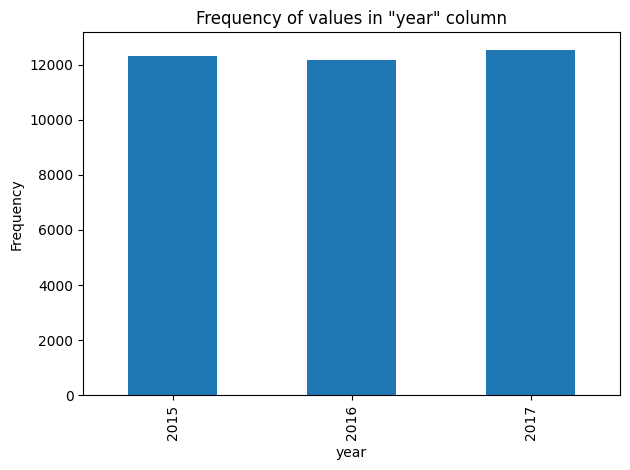

In [ ]:
plot_categorical_frequency('year', df_new)

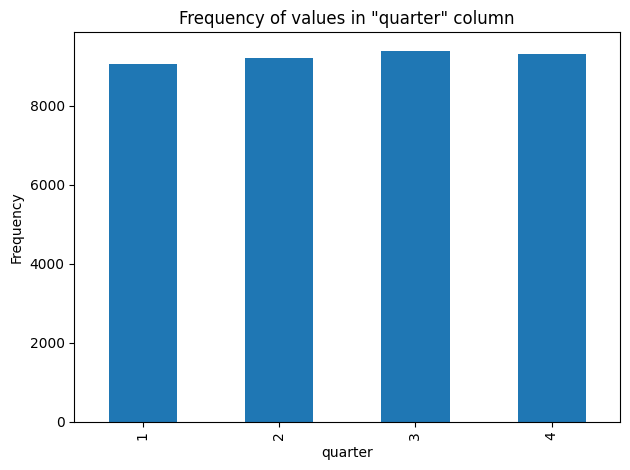

In [ ]:
plot_categorical_frequency('quarter', df_new)

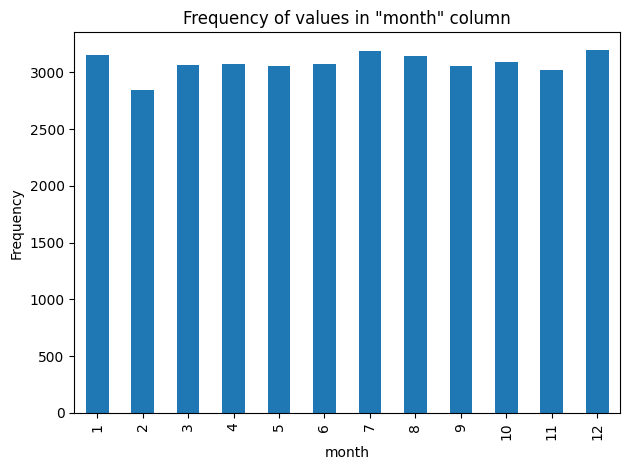

In [ ]:
plot_categorical_frequency('month', df_new)

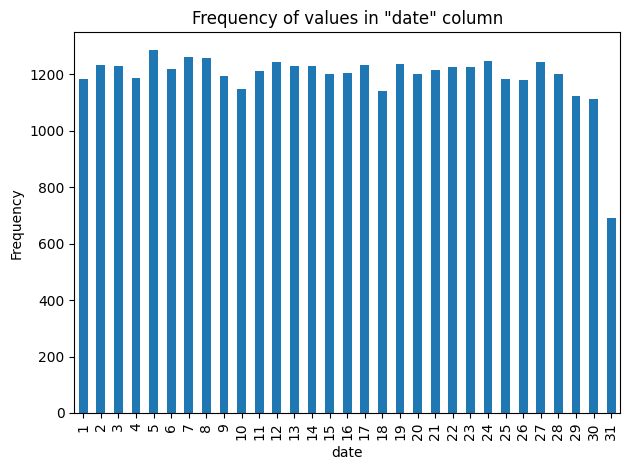

In [ ]:
plot_categorical_frequency('date', df_new)

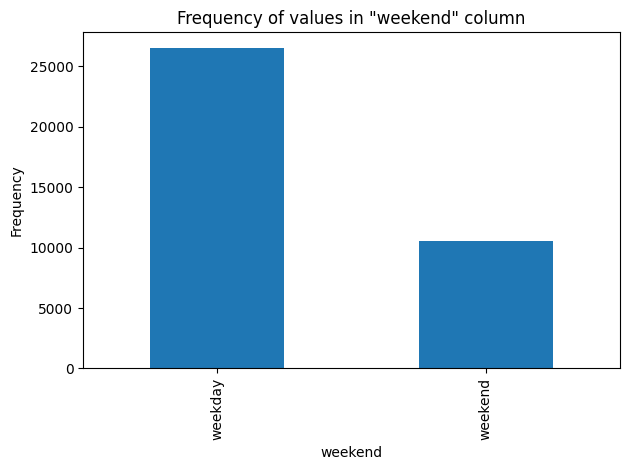

In [ ]:
plot_categorical_frequency('weekend', df_new)

## Mixed datatype column

In [7]:
mixed_numerical = ["avg_frequency_login_days"]
df[mixed_numerical].sample(10)

,avg_frequency_login_days
3964,15.0
3192,-9.953600217853655
29886,7.0
8173,26.0
8101,19.0
7966,22.0
12766,15.0
8158,12.0
25198,9.0
16023,13.0


In [8]:
import re
float_pattern = r'^[-+]?\d*\.?\d+$'
df["avg_frequency_login_days"] = df["avg_frequency_login_days"].apply(lambda x : float(x) if bool(re.match(float_pattern, x)) else pd.NA)

In [9]:
number_of_na_in_avg_frequency_login_days = sum(df["avg_frequency_login_days"].isna())
print(number_of_na_in_avg_frequency_login_days)
# Replace NA values with mean of the entire column
df["avg_frequency_login_days"] = df["avg_frequency_login_days"].fillna(df["avg_frequency_login_days"].mean())

3522


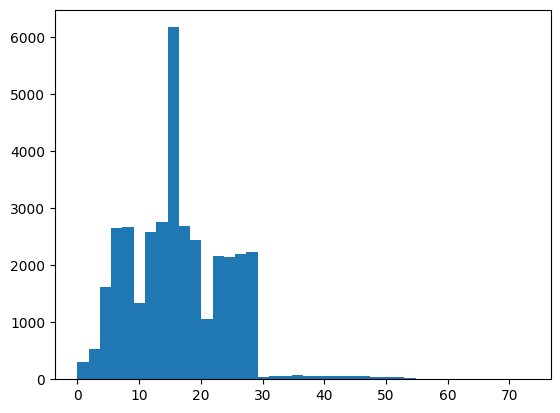

In [10]:
plt.hist(list(df["avg_frequency_login_days"][df["avg_frequency_login_days"] >= 0].values), bins=40)
plt.show()

## Numerical Columns

Columns that have a numerical 

In [11]:
numerical_columns = ["days_since_last_login", "avg_time_spent", "avg_transaction_value", "points_in_wallet", "age", "churn_risk_score"]

In [12]:
df[numerical_columns].describe()

,days_since_last_login,avg_time_spent,avg_transaction_value,points_in_wallet,age,churn_risk_score
count,36992.000000,36992.000000,36992.000000,33549.000000,36992.000000,36992.000000
mean,-41.915576,243.472334,29271.194003,686.882199,37.118161,0.540982
std,228.819900,398.289149,19444.806226,194.063624,15.867412,0.498324
min,-999.000000,-2814.109110,800.460000,-760.661236,10.000000,0.000000
25%,8.000000,60.102500,14177.540000,616.150000,23.000000,0.000000
50%,12.000000,161.765000,27554.485000,697.620000,37.000000,1.000000
75%,16.000000,356.515000,40855.110000,763.950000,51.000000,1.000000
max,26.000000,3235.578521,99914.050000,2069.069761,64.000000,1.000000


#### `age`

In [13]:
plot_categorical_frequency("age", df)

NameError: name 'plot_categorical_frequency' is not defined

#### `avg_time_spent`

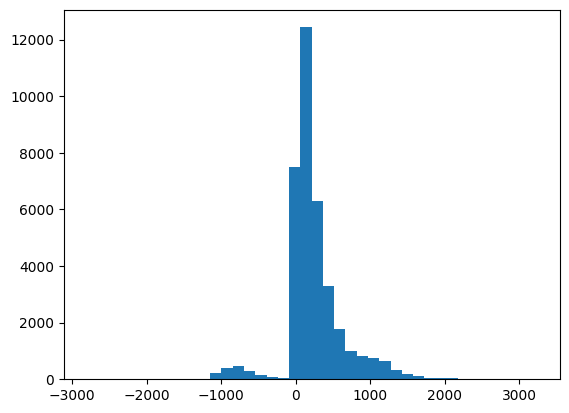

In [14]:
plt.hist(list(df["avg_time_spent"].values), bins=40)
plt.show()

#### `avg_transaction_value`

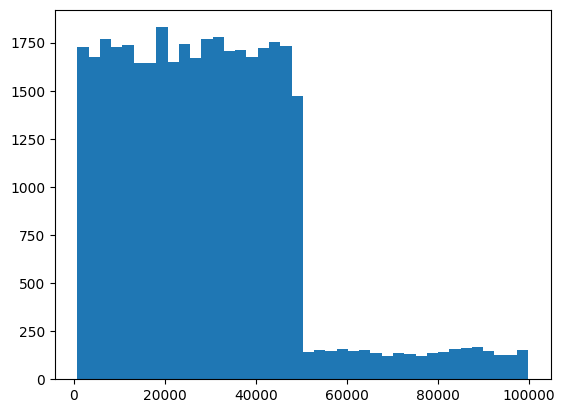

In [15]:
plt.hist(list(df["avg_transaction_value"].values), bins=40)
plt.show()

#### `points_in_wallet`

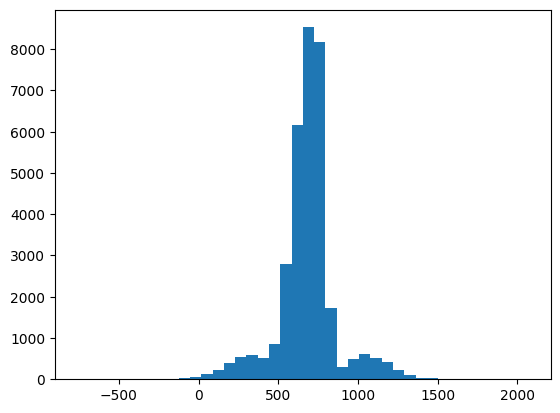

In [16]:
plt.hist(list(df["points_in_wallet"].values), bins=40)
plt.show()

Negative values look like calculation errors - recommended strategy is to replace with absolute value.

#### `days_since_last_login`

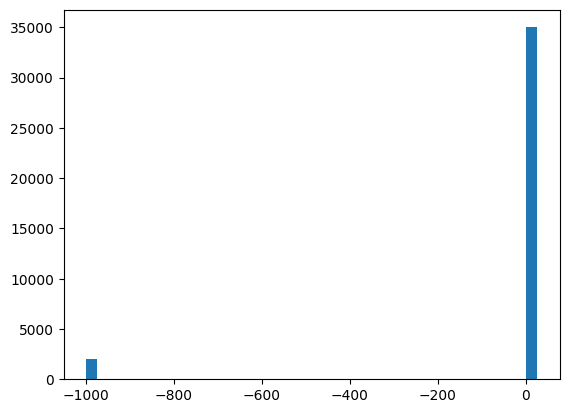

In [17]:
plt.hist(list(df["days_since_last_login"].values), bins=40)
plt.show()

Only a single negative value of -999. The recommended strategy is to replace with median.

### Data cleaning

1. Observed missing and negative values like in `avg_frequency_login_days` - missing were replaced with average, for negative? 
2. Observed negative values in `avg_frequency_login_days`, `avg_time_spent`, `points_in_wallet`

In [21]:
# Replace -999 with median of days_since_last_login
df.loc[df["days_since_last_login"] < 0, "days_since_last_login"] = pd.NA
df["days_since_last_login"] = df["days_since_last_login"].fillna(df["days_since_last_login"].median()) # TODO change this to +- a few days generated at random, centered at the median

In [22]:
cols_with_negatives = ['avg_frequency_login_days', 'avg_time_spent', 'points_in_wallet']
for col in cols_with_negatives:
    neg_count = (df[col] < 0).sum()
    print(f"{col} has {neg_count} negative values")

# avg_frequency_login_days has 683 negative values
# avg_time_spent has 1719 negative values
# points_in_wallet has 136 negative values

avg_frequency_login_days has 683 negative values
avg_time_spent has 1719 negative values
points_in_wallet has 136 negative values


In [23]:
# Replace with absolute value, values are not as numerous as to change the distribution massively # TODO 
cols_to_fix = ['avg_frequency_login_days', 'avg_time_spent', 'points_in_wallet']

for col in cols_to_fix:
    df[col] = df[col].abs()

## Visualizing relationship to churn

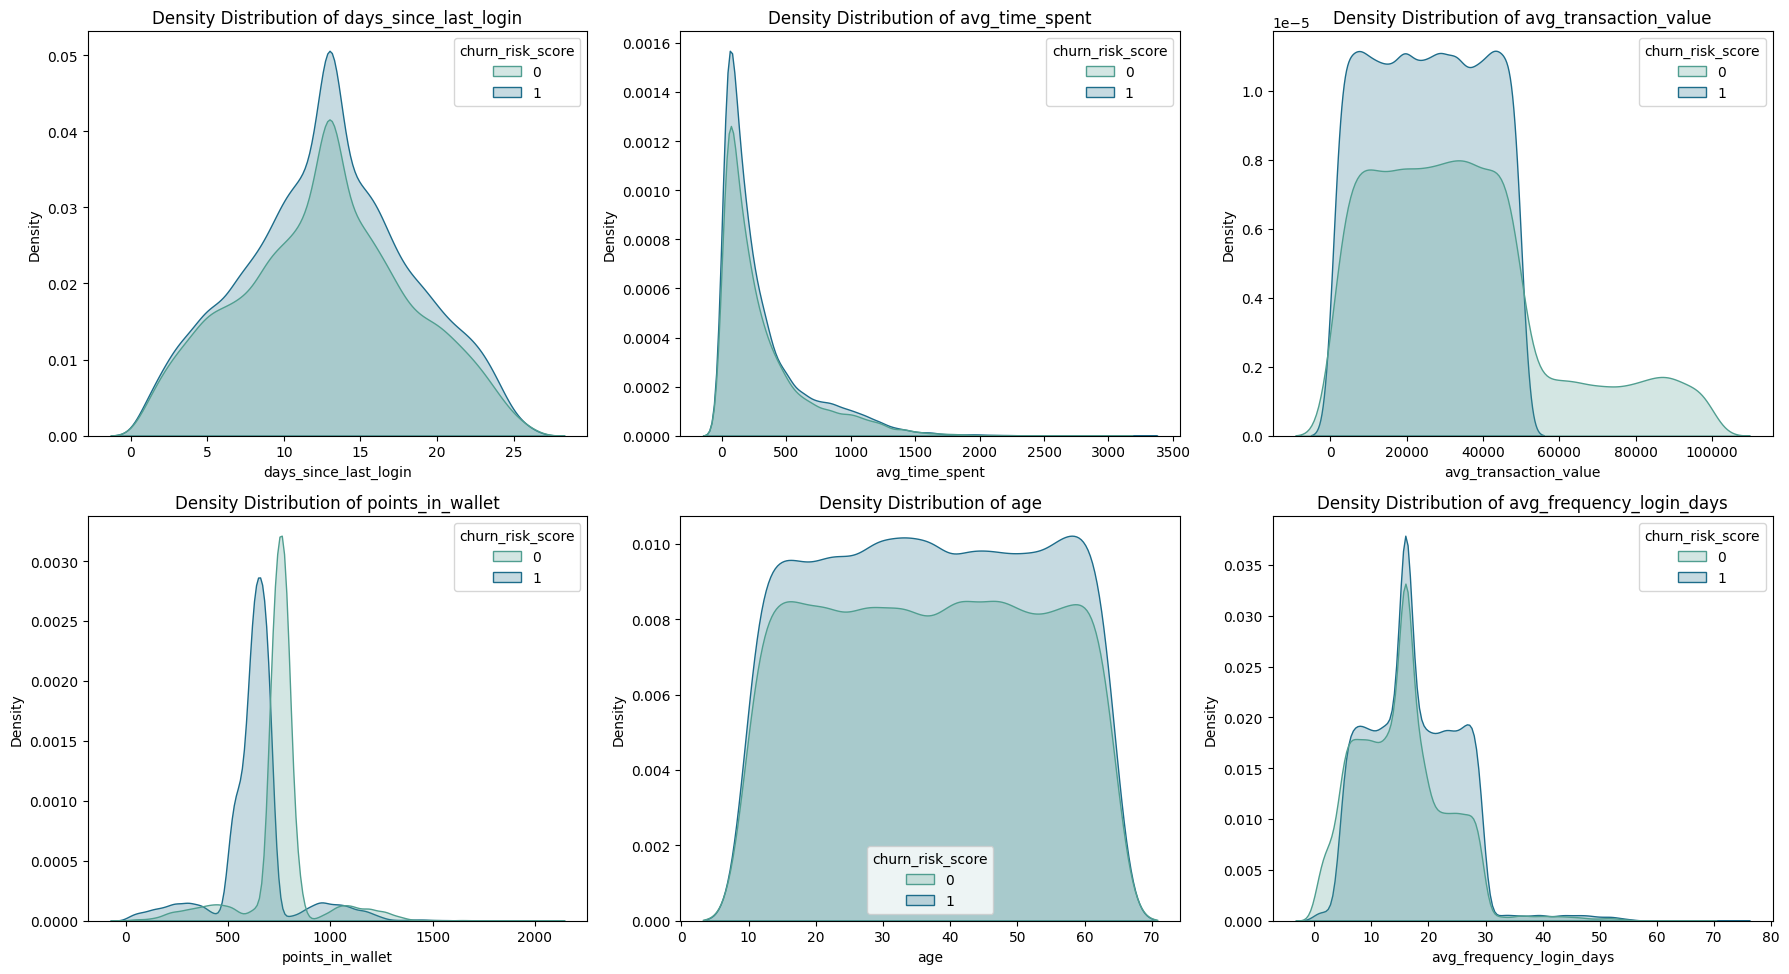

In [30]:
# Updated list of numeric columns
num_cols = ['days_since_last_login', 'avg_time_spent', 'avg_transaction_value', 'points_in_wallet', 'age', "avg_frequency_login_days"]

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.kdeplot(data=df, x=col, hue='churn_risk_score', fill=True, ax=axes[i], palette='crest')
    axes[i].set_title(f'Density Distribution of {col}')
    axes[i].set_xlabel(col)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Observations:

1. Interestingly, the KDEs of `days_since_last_login` and `avg_time_spent`, show no separation between churners and non-churners.
2. `avg_transaction_value` and `points_in_wallet` do show a separation between churners and non-churners. Non-churners tend to have higher `points_in_wallet`, and their `avg_transaction_value` also seems to be high.
3. `avg_frequency_login_days` is higher for churners, whereas non-churners tend to be on the lower end.


#### Points per dollar spent?

<Axes: xlabel='points_per_dollar', ylabel='Density'>

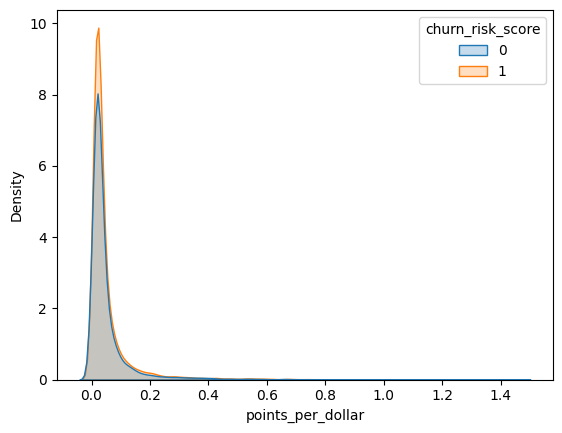

In [25]:
df['points_per_dollar'] = df['points_in_wallet'] / (df['avg_transaction_value'] + 1)
sns.kdeplot(data=df, x='points_per_dollar', hue='churn_risk_score', fill=True)

Observations:

1. If you spend less points per dollar, you are more likely to be a churner than a non-churner.

<Axes: xlabel='avg_time_spent', ylabel='Density'>

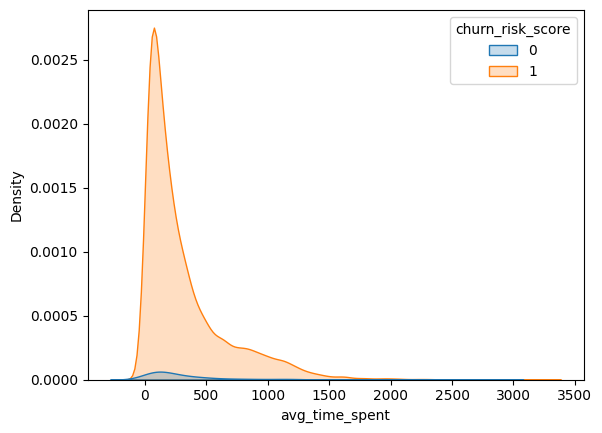

In [28]:
# Check KDE for just the Basic Tier
sns.kdeplot(data=df[df['membership_category'].isin(['Basic Membership', 'No Membership'])],
            x='avg_time_spent', hue='churn_risk_score', fill=True)

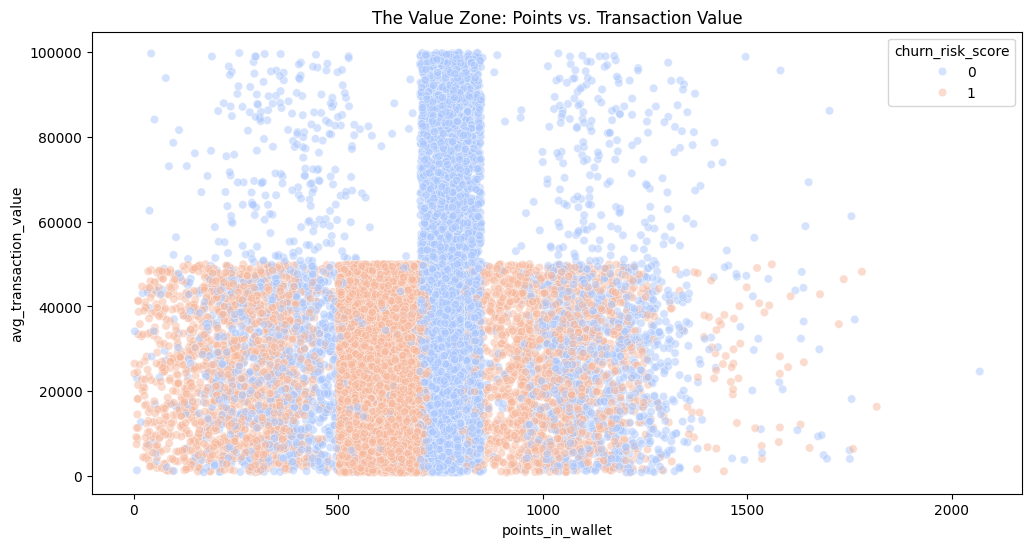

In [31]:
# Scatter plot to see the interaction between the two strongest numeric signals
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='points_in_wallet', y='avg_transaction_value', 
                hue='churn_risk_score', alpha=0.5, palette='coolwarm')
plt.title('The Value Zone: Points vs. Transaction Value')
plt.show()

## All other columns

In [54]:
other_columns = set(df.columns) - set(numerical_columns) - set(unclear_value_add_columns) - set(mixed_numerical) - set(date_time_based_columns)
other_columns

{'complaint_status',
 'feedback',
 'gender',
 'internet_option',
 'joined_through_referral',
 'medium_of_operation',
 'membership_category',
 'offer_application_preference',
 'past_complaint',
 'preferred_offer_types',
 'region_category',
 'used_special_discount'}

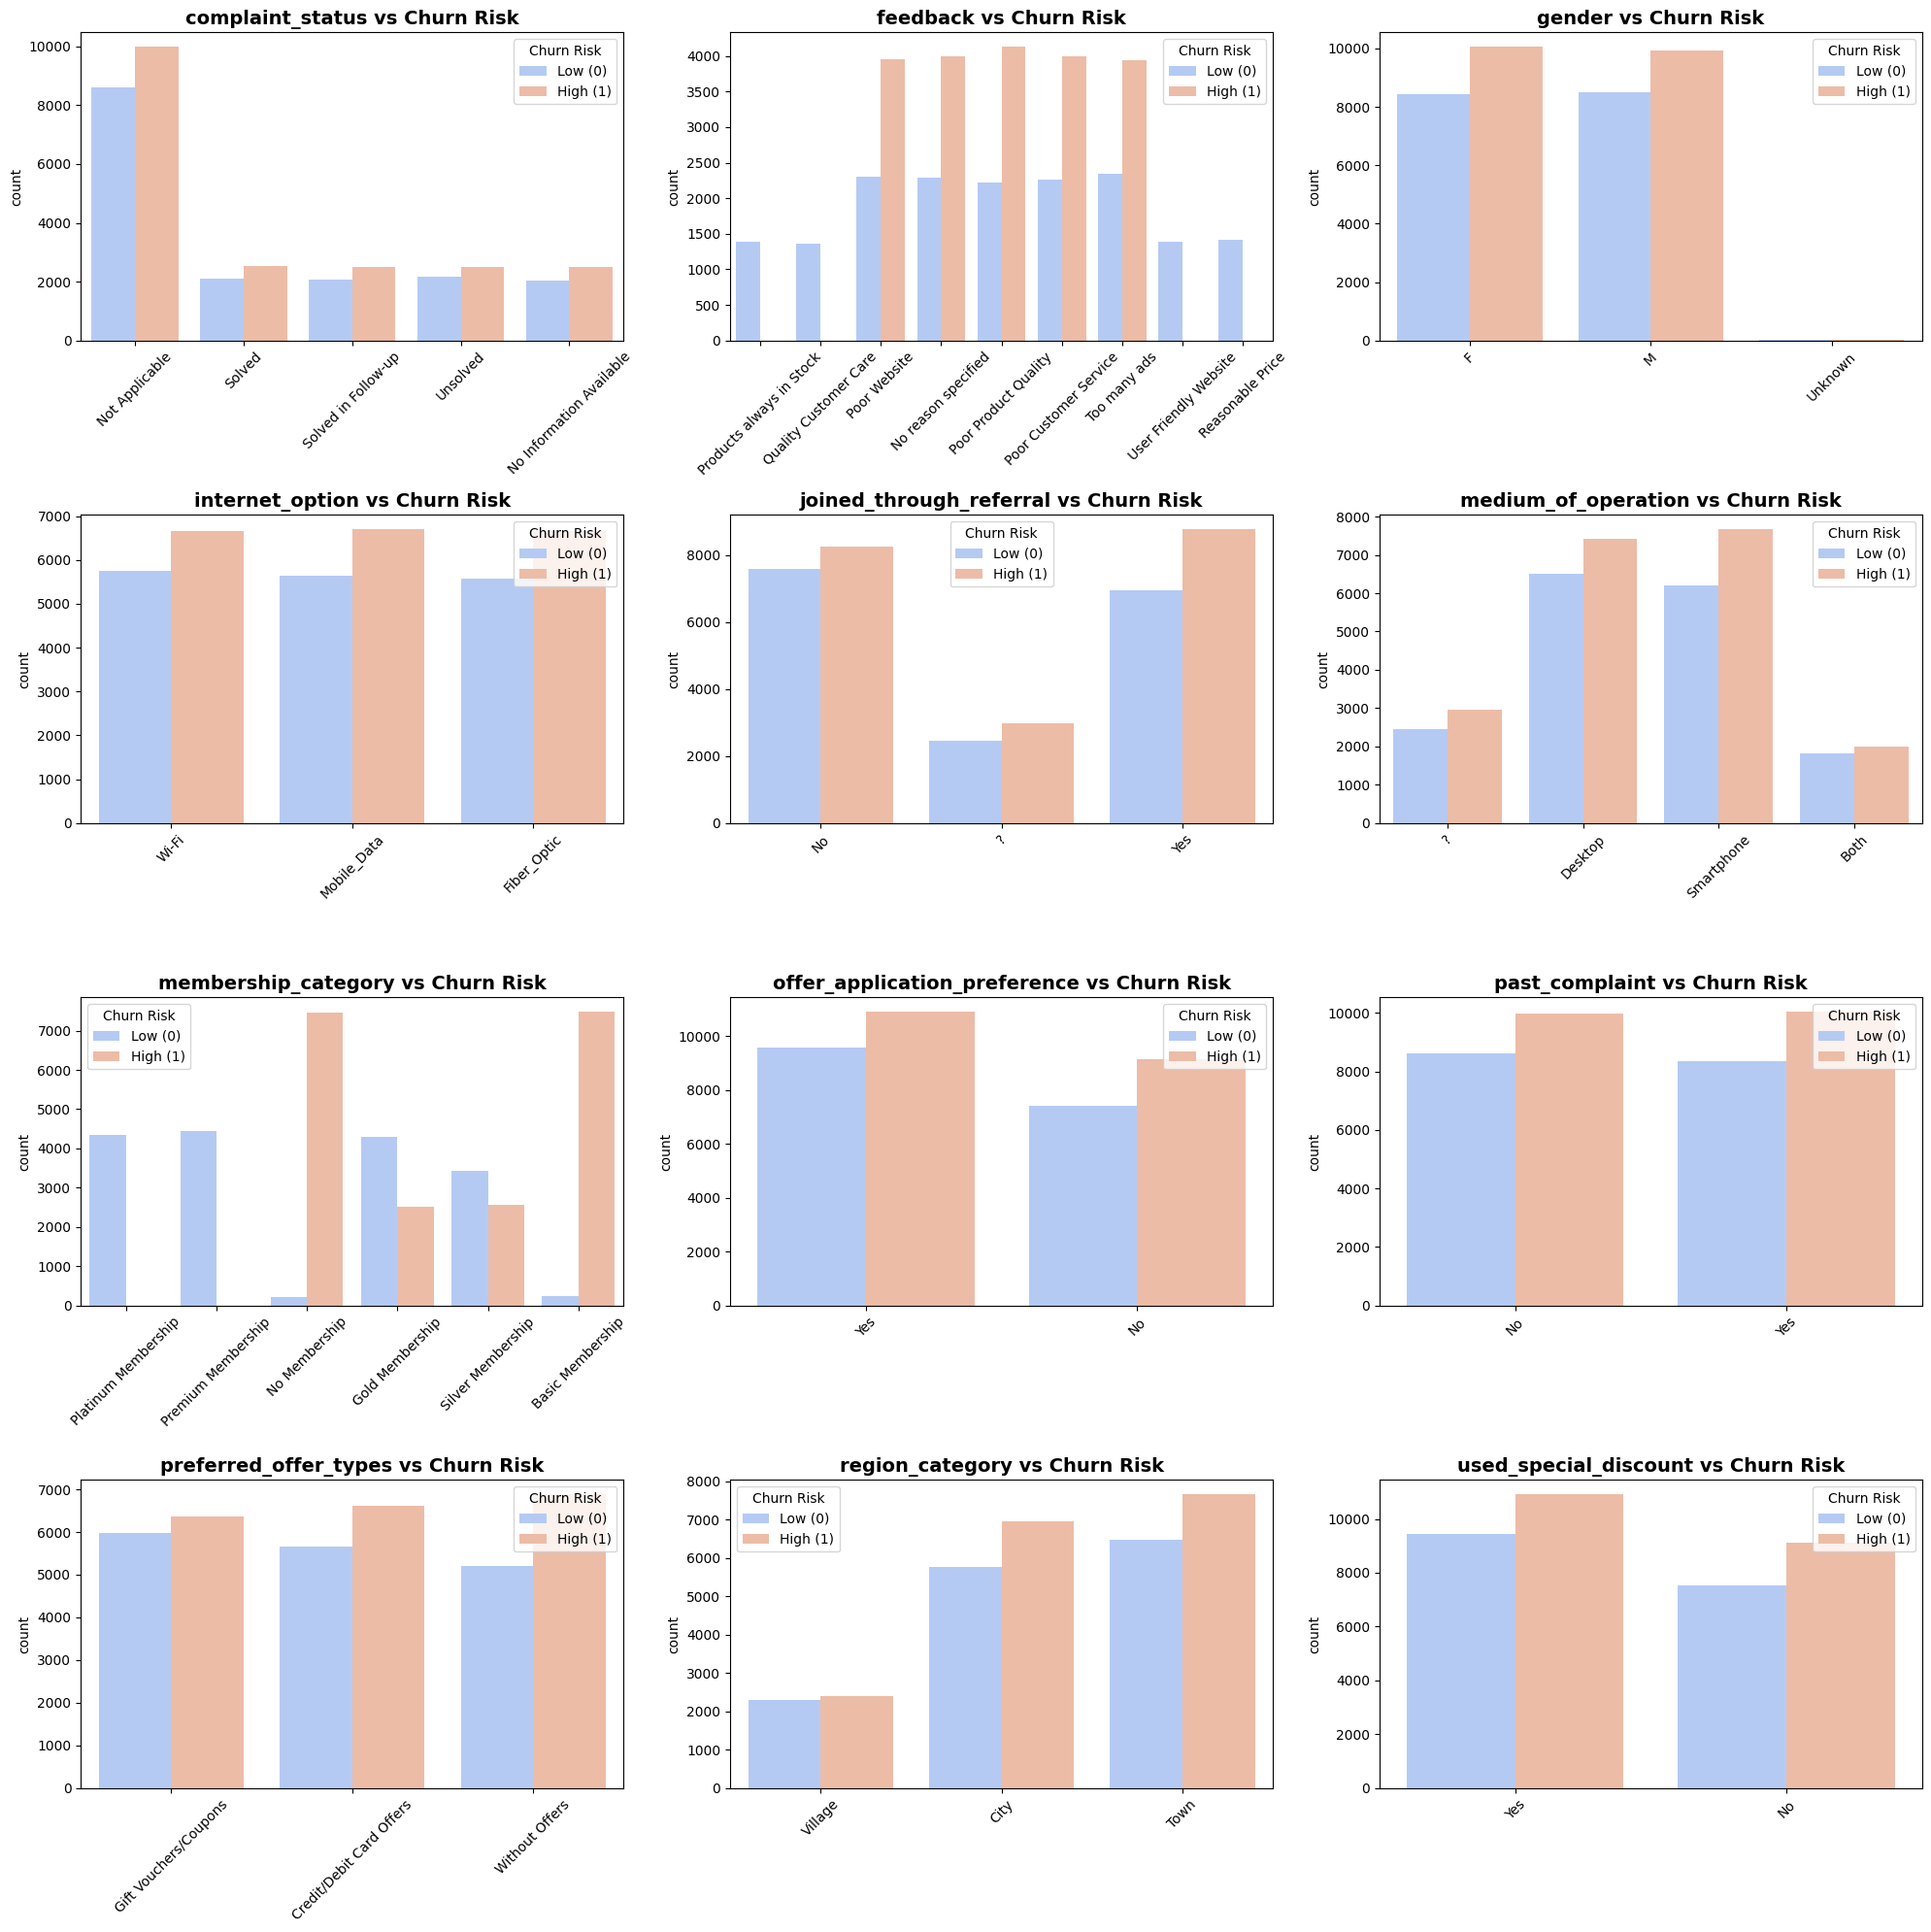

In [60]:
cat_cols = [
    'complaint_status', 'feedback', 'gender', 'internet_option', 
    'joined_through_referral', 'medium_of_operation', 'membership_category', 
    'offer_application_preference', 'past_complaint', 'preferred_offer_types', 
    'region_category', 'used_special_discount'
]

target = 'churn_risk_score'

# Define grid
n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Plotting count with target hue
    sns.countplot(data=df, x=col, hue=target, ax=axes[i], palette='coolwarm')
    
    axes[i].set_title(f'{col} vs Churn Risk', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Churn Risk', labels=['Low (0)', 'High (1)'])

# Clean up empty slots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

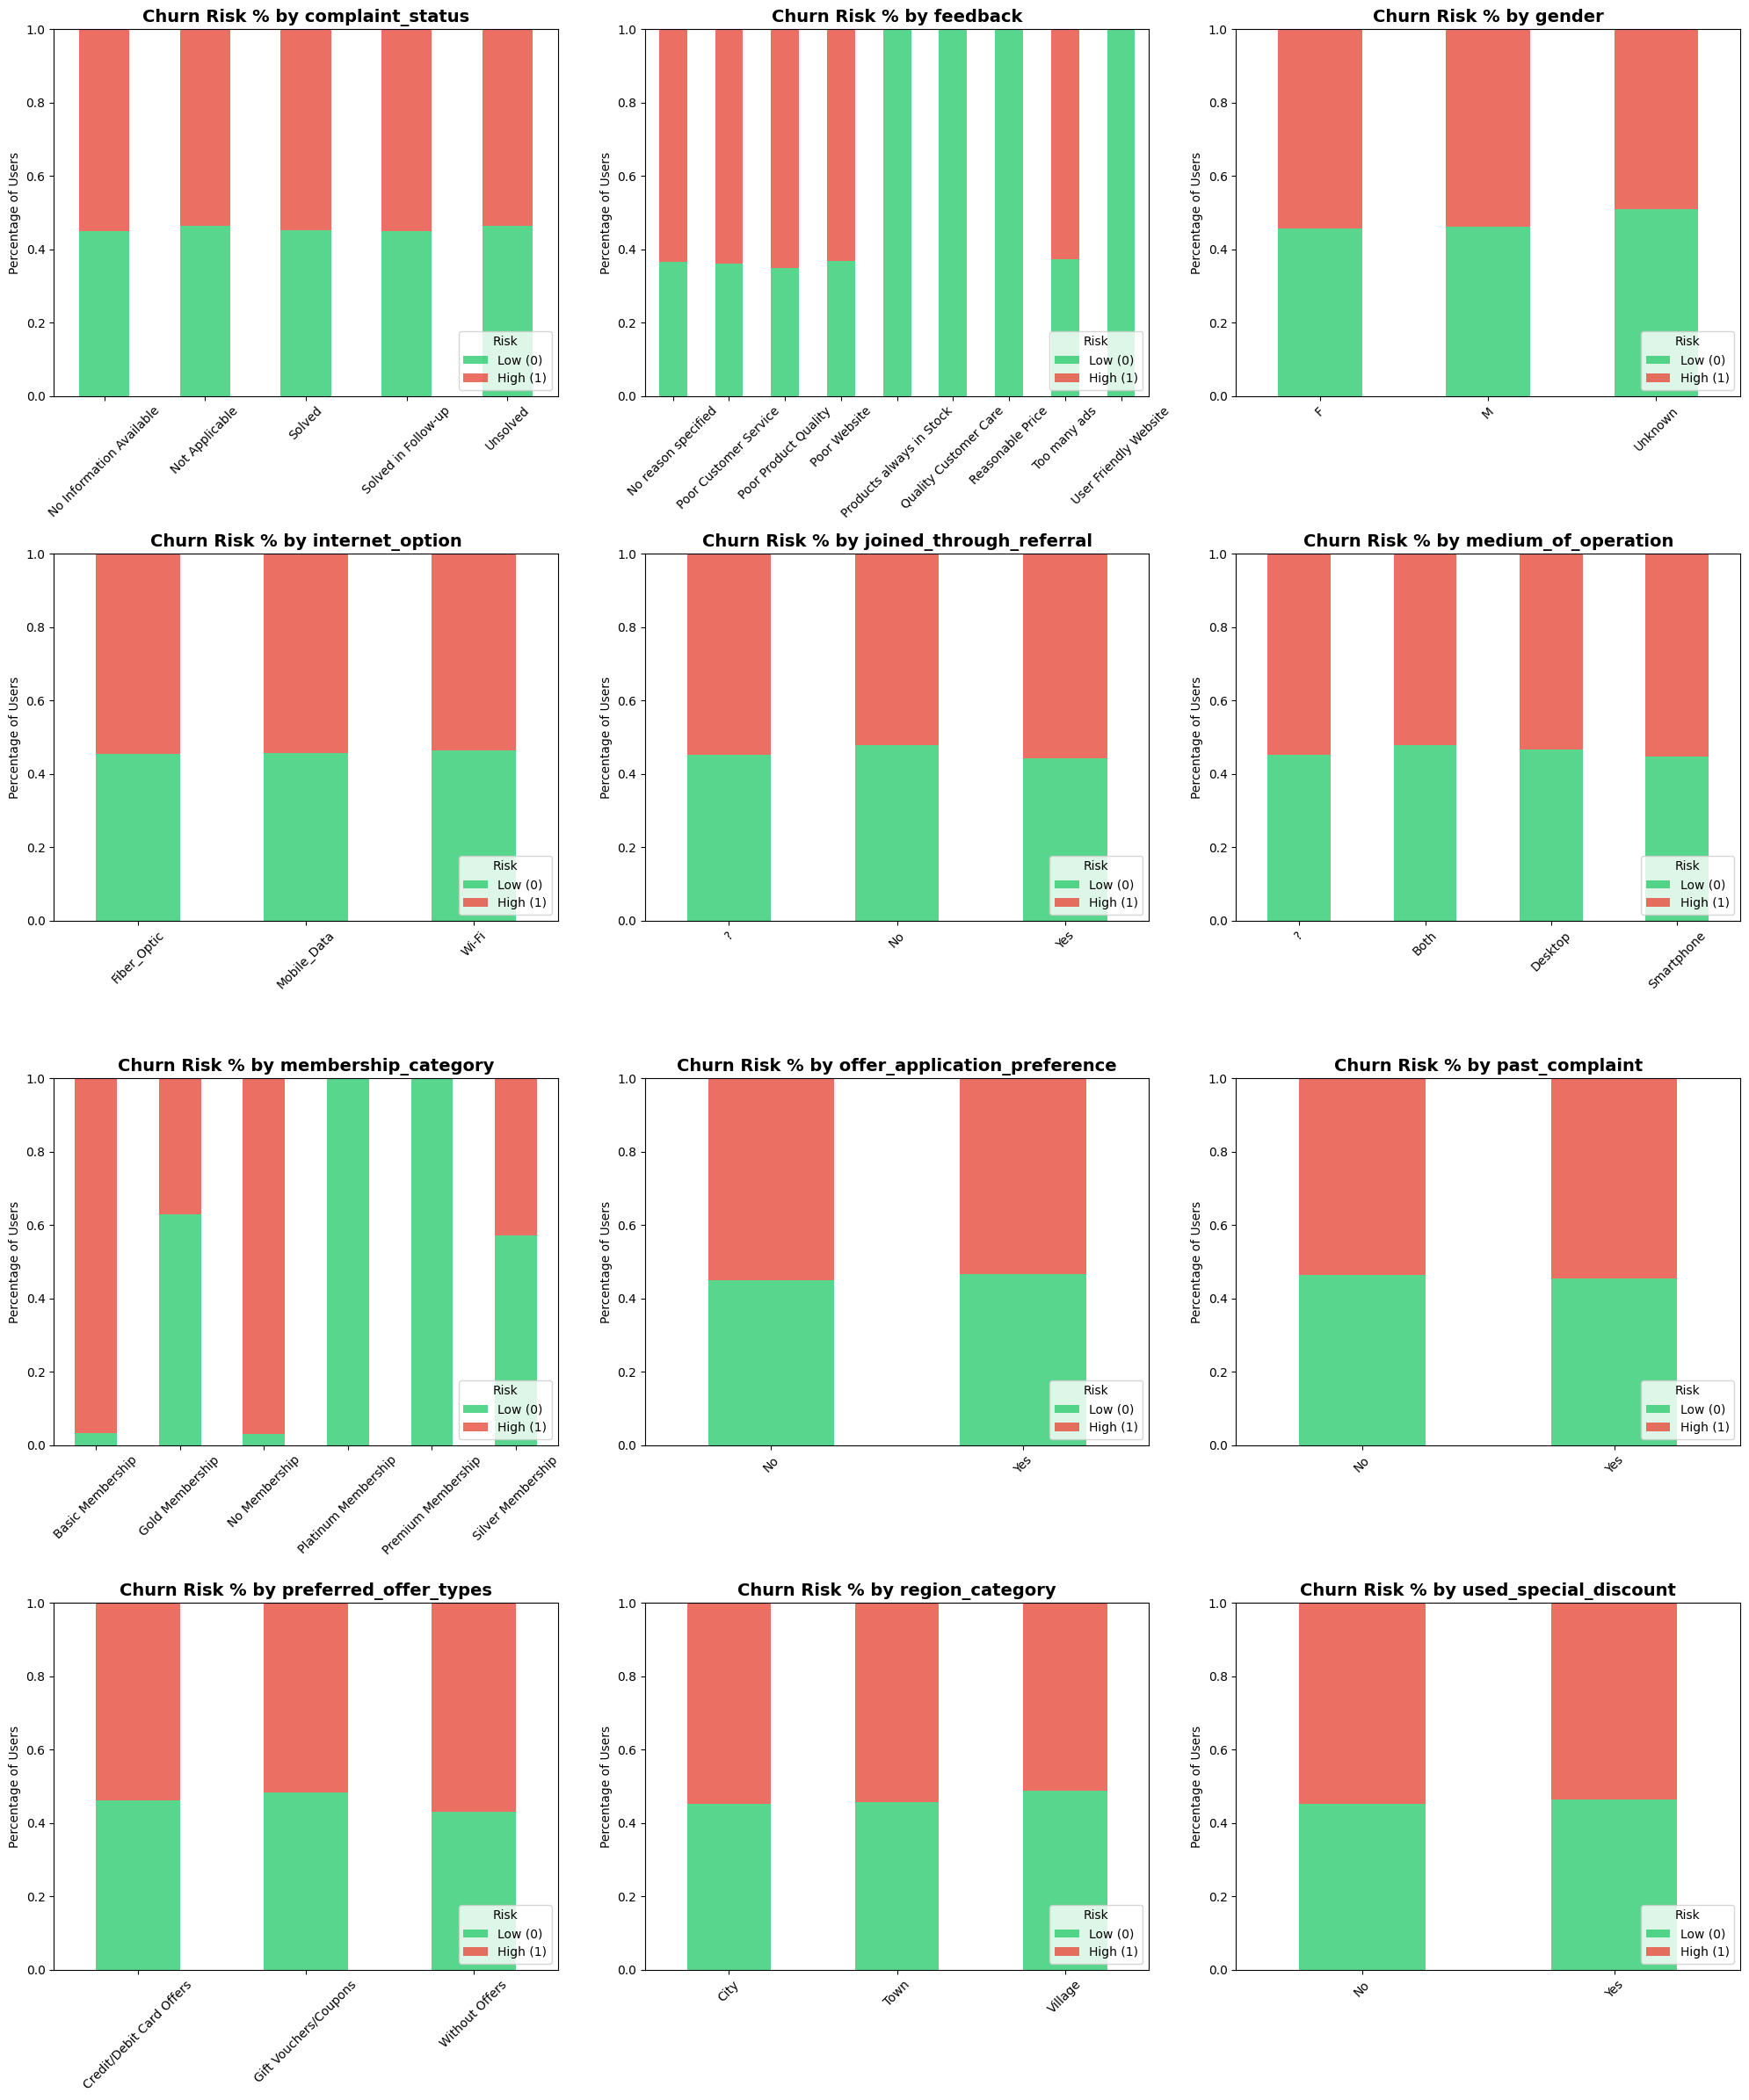

In [63]:
cat_cols = [
    'complaint_status', 'feedback', 'gender', 'internet_option', 
    'joined_through_referral', 'medium_of_operation', 'membership_category', 
    'offer_application_preference', 'past_complaint', 'preferred_offer_types', 
    'region_category', 'used_special_discount'
]

target = 'churn_risk_score'

# Grid setup
n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 6))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # 1. Create a cross-tabulation and normalize by row (index)
    # This turns counts into percentages that sum to 1.0 (100%)
    cross_tab = pd.crosstab(df[col], df[target], normalize='index')
    
    # 2. Plot as a stacked bar chart
    cross_tab.plot(kind='bar', stacked=True, ax=axes[i], color=['#2ecc71', '#e74c3c'], alpha=0.8)
    
    axes[i].set_title(f'Churn Risk % by {col}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Percentage of Users')
    axes[i].set_xlabel('')
    axes[i].set_ylim(0, 1) # Force 0 to 100% scale
    axes[i].legend(title='Risk', labels=['Low (0)', 'High (1)'], loc='lower right')
    axes[i].tick_params(axis='x', rotation=45)

# Clean up empty slots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

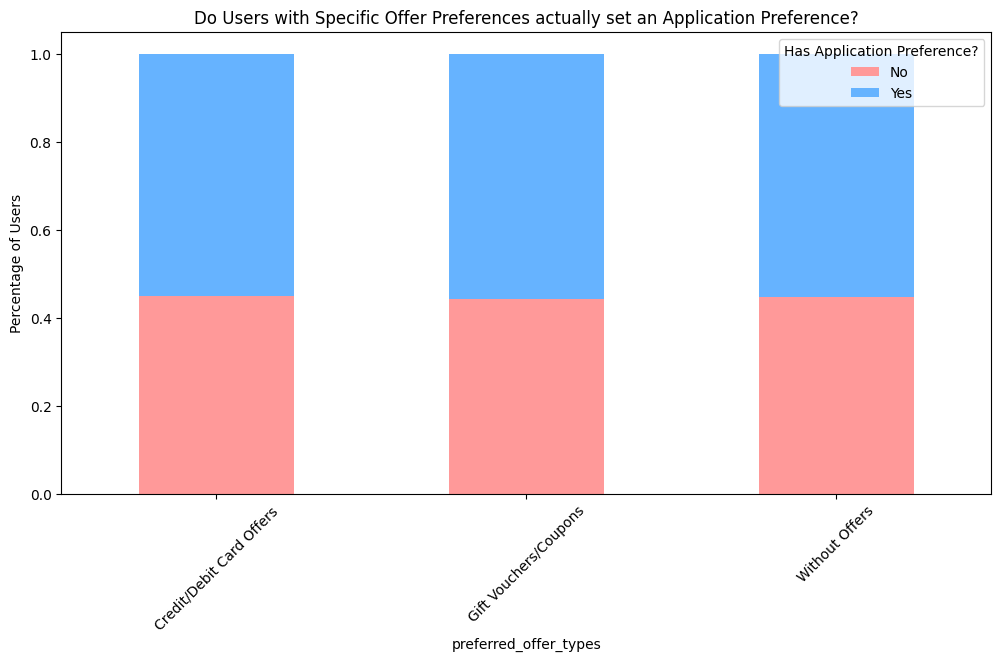

In [56]:
# Cross-tabulate and plot
plt.figure(figsize=(12, 6))
ct = pd.crosstab(df['preferred_offer_types'], df['offer_application_preference'], normalize='index')

ct.plot(kind='bar', stacked=True, color=['#ff9999','#66b3ff'], ax=plt.gca())
plt.title('Do Users with Specific Offer Preferences actually set an Application Preference?')
plt.ylabel('Percentage of Users')
plt.legend(title='Has Application Preference?', loc='upper right')
plt.xticks(rotation=45)
plt.show()

### Aspects to think about

Membership tiers are clear indicators of churn risk, and also the feedback, negative feedback being a good indicator of churn. I am struggling to understand these columns from a timeline perspective though. With the churn_risk_score being 0 or 1, is feedback collected after churn has occurred? Also what does risk being 0 or 1 mean? Is it recording an event?

Bit of analysis for that:

In [ ]:
# Check how many 'Risk 0' people actually give negative feedback
mismatch = df[(df['churn_risk_score'] == 0) & (df['feedback'].str.contains('Poor|No|Too', na=False))]
print(f"Users with bad feedback who haven't churned: {len(mismatch)}")

Users with bad feedback who haven't churned: 20012


This leads us to believe that the feedback can be used in the modelling because it isn't something that is collected at the moment of churn. Possibly something collected while the user is still active.